# Ottawa Neighbourhood Safety — Model Building

This notebook takes the cleaned dataset (`CleanedData.csv`) and applies K-Means clustering to group Ottawa's 104 neighbourhoods into distinct safety profiles. The output is `ClusteredData.csv` — the same dataset with a `cluster` column added, ready for analysis in the Cluster Analysis notebook.

---

## Input

`CleanedData.csv` — 104 neighbourhoods × 24 columns (18 crime counts, 3 police response counts, population, geometry, neighbourhood name). Produced by the Data Cleaning notebook.

---

## Pipeline Overview

### Step 1 — Determine the optimal number of clusters (K)
---

### Step 2 — Fit the final model
---

### Step 3 — Assign clusters and export


**Output: `ClusteredData.csv`** — 104 neighbourhoods × 25 columns (all input columns + `cluster`).

In [209]:
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ML Model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


#### Reading the data

In [210]:
# import data
df = pd.read_csv('CleanedData.csv')

print(f'Data loaded. Shape: {df.shape}')
df.head(2)

Data loaded. Shape: (104, 24)


,Neighbourhood,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Homicide,Shootings,Other,Population,Police_Critical,Police_High,Police_Medium,geometry
0,Barrhaven,3,208,0,79,258,10,171,0,59,346,9,3,4,103.0,61.0,3.0,2.0,563.0,39166,185,2592,5100,"POLYGON ((-75.7742283499069 45.2610220238087, ..."
1,Bayshore,3,278,1,129,244,6,203,11,73,1722,42,0,5,119.0,90.0,0.0,8.0,665.0,9313,80,1089,2501,"POLYGON ((-75.802358463964 45.3572739626829, -..."


In [211]:
# check quick stats of the data
df.describe()

,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Homicide,Shootings,Other,Population,Police_Critical,Police_High,Police_Medium
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,8.375000,299.394231,0.778846,192.413462,250.442308,15.259615,196.528846,9.519231,66.086538,1126.134615,30.423077,1.173077,6.721154,104.048077,148.269231,1.182692,4.673077,892.105769,8736.307692,130.538462,1686.173077,3094.769231
std,11.341296,436.852720,1.328966,293.000965,305.803790,32.379124,252.190980,15.552592,83.007440,1877.743585,34.249993,1.866632,11.312384,101.837047,341.449601,2.008547,6.034597,2697.980676,7409.850223,212.825053,2364.289616,4310.534376
min,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,17.000000,0.000000,9.000000,19.000000
25%,2.000000,74.750000,0.000000,54.500000,87.000000,2.000000,63.750000,2.000000,19.000000,154.500000,11.000000,0.000000,1.000000,44.750000,13.500000,0.000000,1.000000,231.750000,4245.000000,42.500000,563.750000,949.250000
50%,5.000000,162.500000,0.000000,99.500000,158.000000,6.000000,116.000000,5.000000,43.500000,360.500000,18.500000,0.000000,3.000000,78.000000,44.500000,0.000000,2.000000,395.000000,6805.500000,61.500000,894.000000,1517.500000
75%,9.250000,338.250000,1.000000,207.000000,294.500000,10.000000,238.250000,9.250000,76.000000,1433.500000,35.000000,1.250000,8.250000,129.500000,110.000000,2.000000,5.250000,813.500000,10701.000000,138.250000,1990.000000,3992.500000
max,67.000000,2790.000000,6.000000,2452.000000,2273.000000,205.000000,1983.000000,97.000000,660.000000,11565.000000,236.000000,10.000000,98.000000,605.000000,2437.000000,10.000000,28.000000,27336.000000,46263.000000,1317.000000,18859.000000,28926.000000


## Machine Learning
**Elbow Method (WCSS)**: For each K, a KMeans model is fitted and the Within-Cluster Sum of Squares (inertia) is recorded. The elbow plot shows the rate at which WCSS decreases — the point where the curve bends and additional clusters yield diminishing returns. **K = 6** is selected as the elbow point.

**Silhouette Method**: For each K, the silhouette score (average inter- vs. intra-cluster distance) is computed as a secondary validation. The silhouette scores do not produce a clear peak, so this method is inconclusive and the elbow result is used.

#### 1. Elbow Method
- I'll analyze cluster from 2-11 and calculate the WCSS scores. The WCSS scores can be used to plot the Elbow Plot

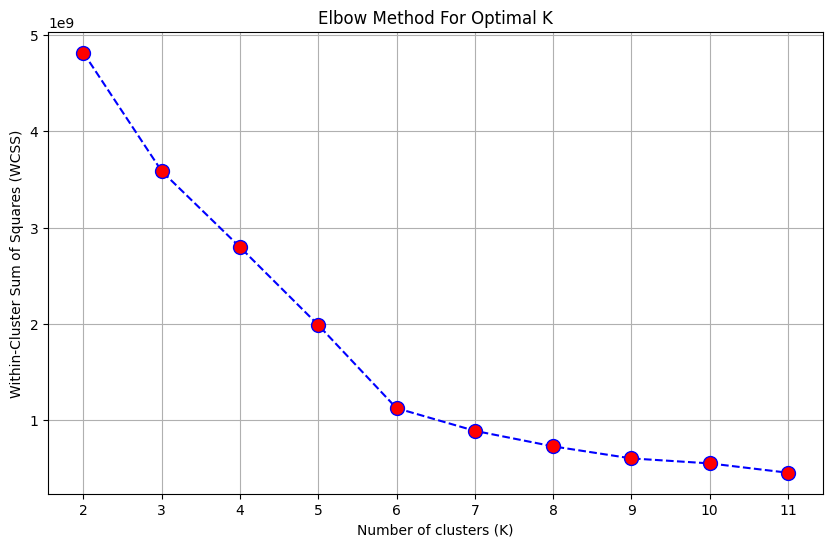

In [212]:
k = range(2, 12)
K = []
WCSS = []
for i in k:
    kmodel = KMeans(n_clusters=i, random_state=42).fit(df.drop(columns=['Neighbourhood','geometry']))
    wcss_score = kmodel.inertia_
    WCSS.append(wcss_score)
    K.append(i)

# store the number of clusters and their corresponding WCSS scores in a DataFrame
elbow_df = pd.DataFrame({'K': K, 'WCSS': WCSS})

# plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(elbow_df['K'], elbow_df['WCSS'], marker='o', color = 'blue', linestyle = '--', markerfacecolor = 'red', markersize = 10)
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K)
plt.grid()
plt.show()

We got 6 clusters as a best value of k using the WSS method

#### 2. Silhoueter Measure
i check the value of K using the Silhouette measure

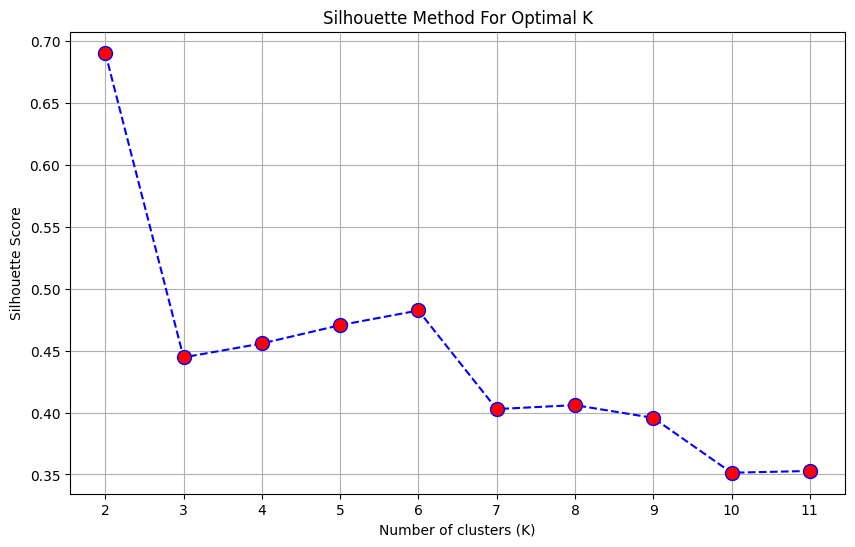

In [213]:
# calculate silhouette scores for k=2-10
k = range(2, 12)
K = []
ss = []
for i in k:
    kmodel = KMeans(n_clusters=i, random_state=42).fit(df.drop(columns=['Neighbourhood','geometry']))
    labels = kmodel.labels_
    sil_score = silhouette_score(df.drop(columns=['Neighbourhood','geometry']), labels)
    ss.append(sil_score)
    K.append(i) 

# store the number of clusters and their corresponding silhouette scores in a DataFrame
elbow_df['Silhouette Score'] = ss

# plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(elbow_df['K'], elbow_df['Silhouette Score'], marker='o', color = 'blue', linestyle = '--', markerfacecolor = 'red', markersize = 10)
plt.title('Silhouette Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K)
plt.grid()
plt.show()

The silhoutte method does not give use a defintive number of clusters we can work with, so we can ignore this method and stick with the elbow.

## Model Building
Now we can start building our model and assigning clusters to each neighbourhood.

A KMeans model is fitted on all 22 numeric features (all columns except `Neighbourhood` and `geometry`) with the following configuration:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_clusters` | 6 | Elbow method |
| `init` | `k-means++` | Smart centroid initialisation — reduces sensitivity to random starting points |
| `max_iter` | 100 | Maximum iterations per run |
| `n_init` | `auto` | Number of random initialisations |
| `random_state` | 42 | Reproducibility |

Features are **standardised with `StandardScaler`** before fitting so that high-magnitude columns (e.g. `Theft $5000 and Under`, `Police_Medium`) do not dominate the distance calculation over lower-magnitude ones (e.g. `Homicide`, `Arson`).

In [ ]:
x = df.drop(columns=['Neighbourhood','geometry'])

# scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

model = KMeans(n_clusters = 6,
                init = 'k-means++',
                max_iter = 100,
                n_init = 'auto',
                random_state = 42)

Each neighbourhood is assigned to its cluster (0–5) via `fit_predict`. A bar chart shows the distribution of neighbourhoods across clusters. 

In [ ]:
# fit and predict
df['cluster'] = model.fit_predict(x_scaled)

Here is our cluster distribution showing number of neighbourhoods in each cluster.

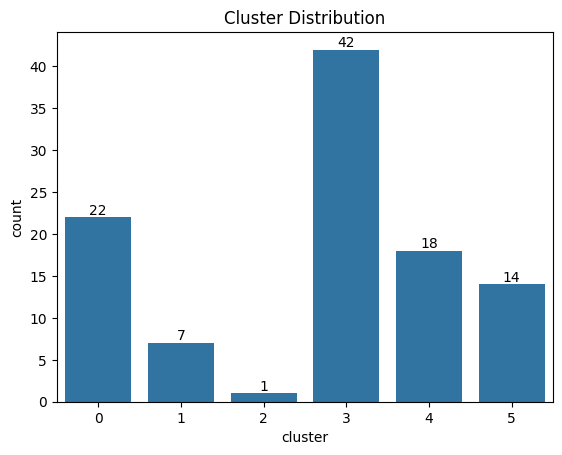

In [223]:
# view cluster counts
ax = sns.countplot(x="cluster", data=df)
plt.title("Cluster Distribution")

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height(),
            str(int(p.get_height())), ha="center", va="bottom")

plt.show()

The labelled dataframe is exported as `ClusteredData.csv`.

In [ ]:
df.to_csv('ClusteredData.csv', index=False)
print('Clustered data saved.')